### Step 1: Import Libraries

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, date
import holidays

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae

In [4]:
from xgboost import XGBRegressor

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [48]:
df = pd.read_csv('./data/inventory_demand_forecasting_data.csv')

In [49]:
df.shape

(913000, 4)

In [50]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [51]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


### Step 3: Feature Engineering

In [53]:
parts = df['date'].str.split('-', n=3, expand=True)

In [54]:
df['year'] = parts[0].astype('int')
df['month'] = parts[1].astype('int')
df['day'] = parts[2].astype('int')

In [55]:
def weekend_or_weekday(year, month, day):
    d = datetime(year, month, day)
    return 1 if d.weekday() > 4 else 0

In [56]:
df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)

In [57]:
india_holidays = holidays.country_holidays('IN')

In [58]:
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)

In [59]:
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))

In [60]:
def which_day(year, month, day):
    return datetime(year, month, day).weekday()

In [61]:
df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis=1)

In [62]:
df['date'] = pd.to_datetime(df['date'])

In [63]:
df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025,1
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025,2
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025,3
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025,4
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025,5


### Step 4: Exploratory Data Analysis

In [64]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

In [65]:
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

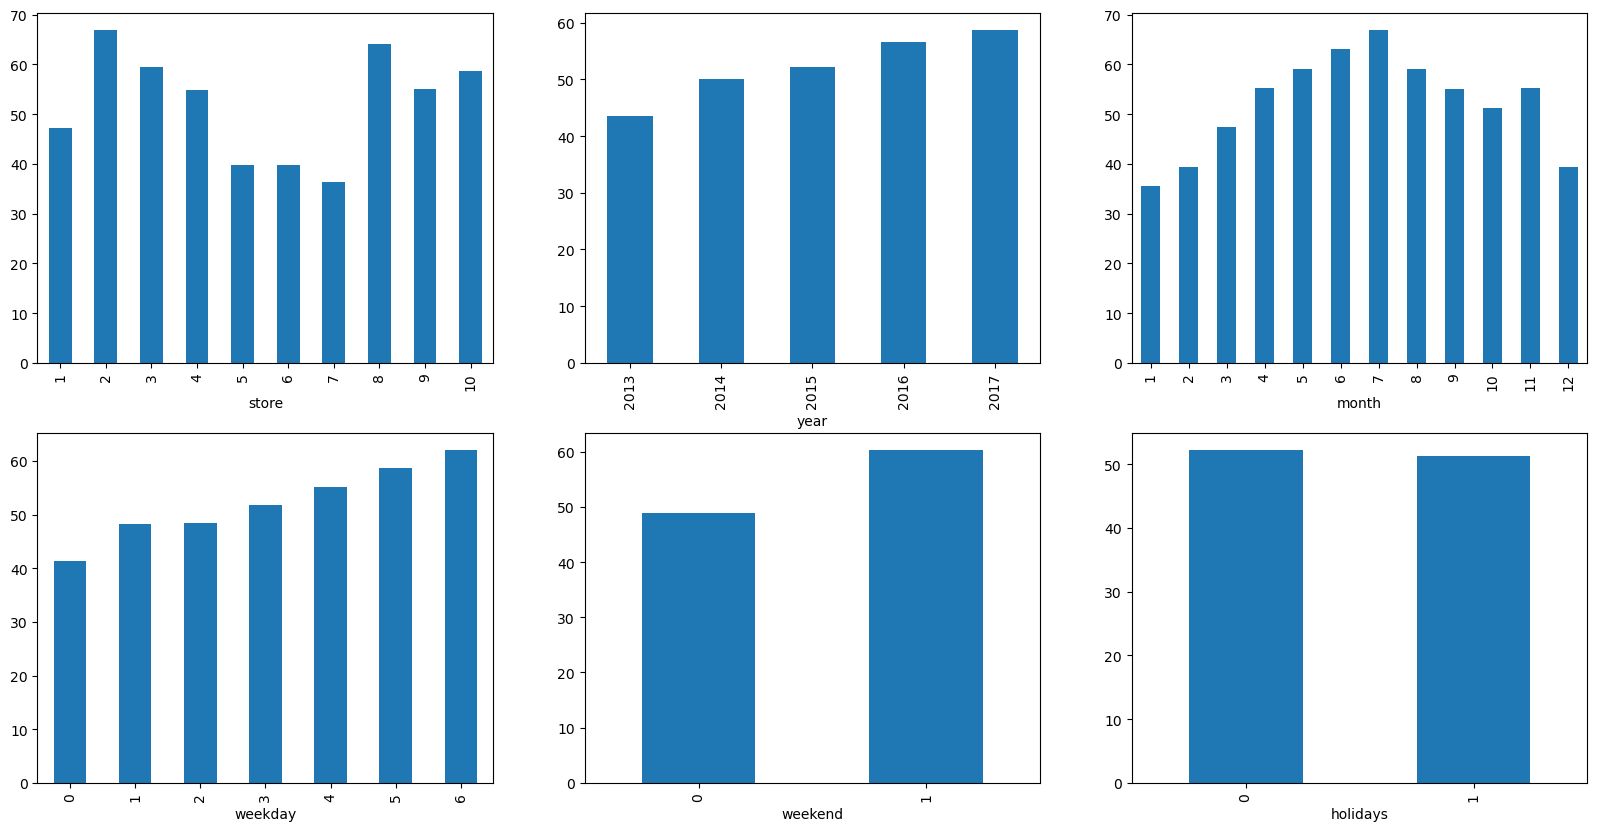

In [66]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['sales'].plot.bar()

<Axes: xlabel='day'>

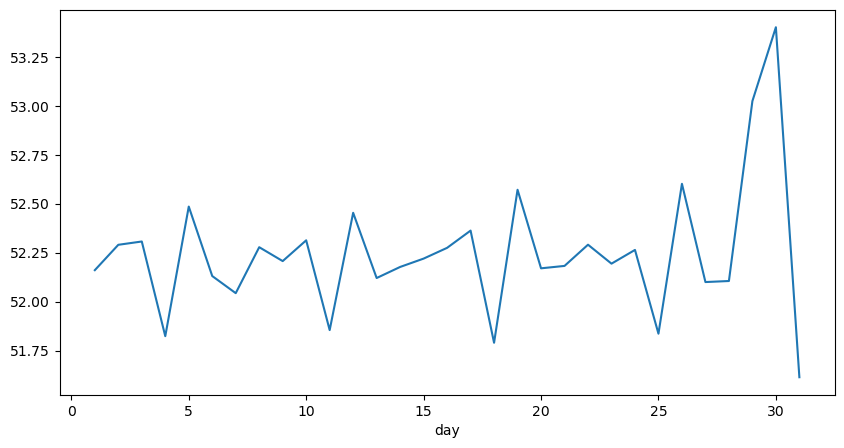

In [67]:
plt.figure(figsize=(10, 5))
df.groupby('day').mean()['sales'].plot()

In [74]:
window_size = 30
data = df[df['year']==2013]
sma = data['sales'].rolling(window_size).mean().dropna()

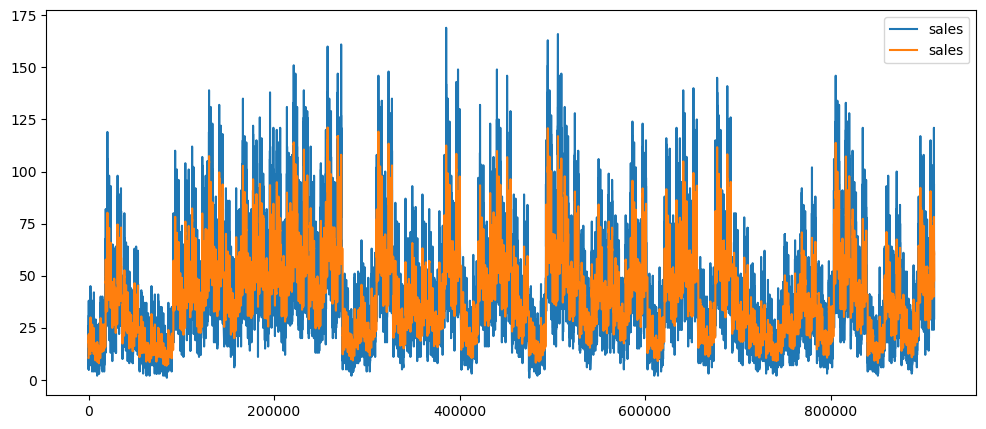

In [79]:
plt.figure(figsize=(12, 5))
data['sales'].plot()
sma.plot()
plt.legend()

<Axes: xlabel='sales'>

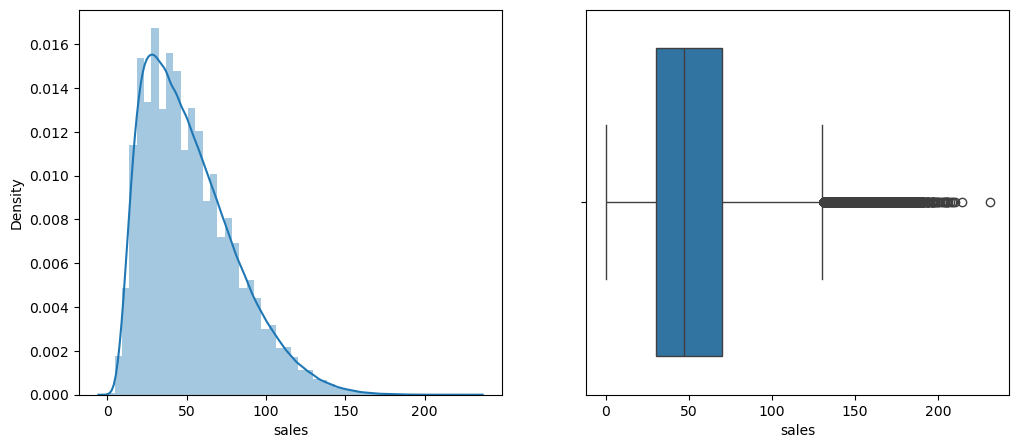

In [81]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.distplot(df['sales'])
plt.subplot(1, 2, 2)
sns.boxplot(df['sales'], orient='h')

<Axes: >

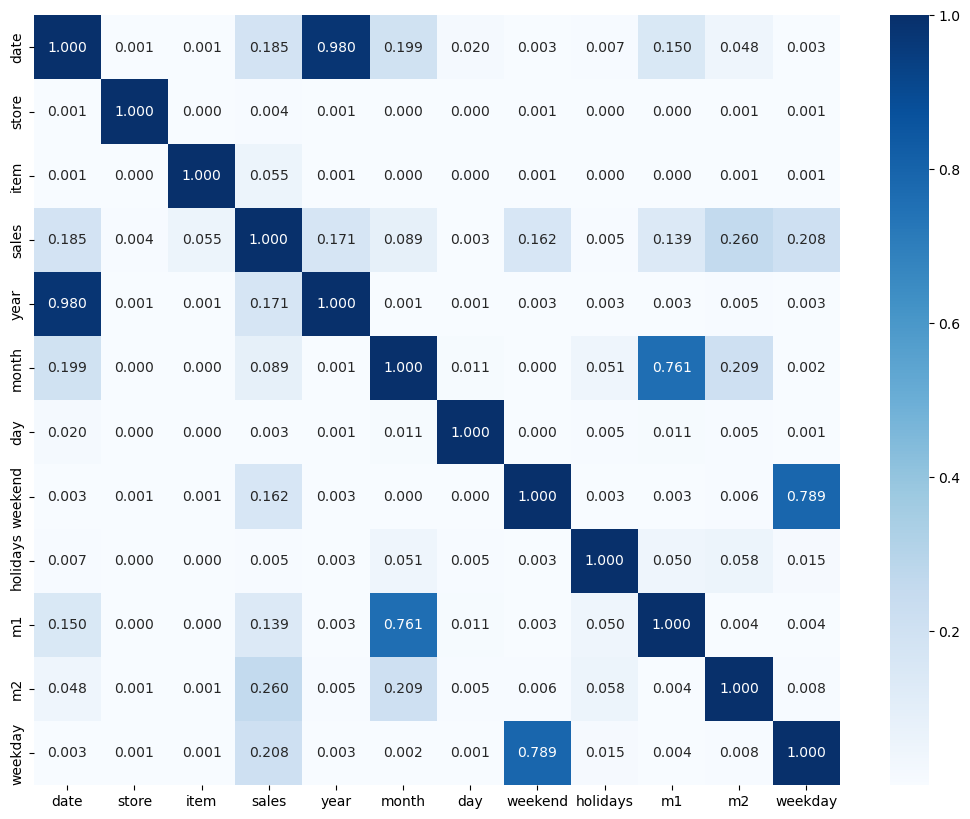

In [91]:
plt.figure(figsize=(13, 10))
sns.heatmap(
    df.corr().abs(),
    annot=True,
    fmt='.3f',
    cmap=plt.cm.Blues
)

### Step 5: Preparing Data

In [101]:
df = df[df['sales'] < 140]

In [102]:
X = df.drop(['date', 'sales', 'year'], axis=1)
y = df['sales']

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [104]:
scaler = StandardScaler()

In [105]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Training and Prediction

In [106]:
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

In [108]:
for model in models:
    model.fit(X_train, y_train)
    print(model)
    train_pred = model.predict(X_train)
    print('Training Error:', mae(y_train, train_pred))
    test_pred = model.predict(X_test)
    print('Testing Error:', mae(y_test, test_pred))
    print('---------------')

LinearRegression()
Training Error: 20.915841742550647
Testing Error: 20.862952068880283
---------------
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
Training Error: 6.885654926300049
Testing Error: 6.938465595245361
---------------
Lasso()
Training Error: 21.02746365314425
Testing Error: 20.979